In [1]:
import gzip
import json
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
RAW_DIR = Path("../data/raw")
OUT_DIR = Path("../eda")
OUT_DIR.mkdir(parents=True, exist_ok=True)

REVIEWS_PATH = RAW_DIR / "Electronics.json.gz"
META_PATH = RAW_DIR / "meta_Electronics.json.gz"

print(REVIEWS_PATH.exists(), REVIEWS_PATH)
print(META_PATH.exists(), META_PATH)

True ..\data\raw\Electronics.json.gz
True ..\data\raw\meta_Electronics.json.gz


In [17]:
def read_json_gz(path, limit=None):
    count = 0
    with gzip.open(path, "r") as f:
        for line in f:
            #if line.strip():
                yield json.loads(line)
                count += 1
                
                if limit is not None and count >= limit:
                    break

In [18]:
for i, row in enumerate(read_json_gz(REVIEWS_PATH, limit=3)):
    print(f"===== REVIEW {i+1} =====")
    print(json.dumps(row, indent=2, ensure_ascii=False))

===== REVIEW 1 =====
{
  "overall": 5.0,
  "verified": true,
  "reviewTime": "07 17, 2002",
  "reviewerID": "A1N070NS9CJQ2I",
  "asin": "0060009810",
  "style": {
    "Format:": " Hardcover"
  },
  "reviewerName": "Teri Adams",
  "reviewText": "This was the first time I read Garcia-Aguilera.  I came upon the name of this book on Live with Regis and Kelly. This book was exactly what I was looking for ... it hit the spot.  I really enjoyed this book because it was well written. Once I started this book it kept me coming back for more. It had culture, family, friendship and romance. I was looking for a little more romance when I picked this book but in the end it turned out to be just right.  I love the main chartachter Margarita (aka Daisy). I've never been to Miami but the way Daisy told the story I certainly felt I'd been there.\nAlso after going through all of Daisy's perils ... I closed the book with a feeling I had grown emotionally as well.",
  "summary": "Hit The Spot!",
  "unixRe

In [19]:
for i, row in enumerate(read_json_gz(META_PATH, limit=3)):
    print(f"===== META {i+1} =====")
    print(json.dumps(row, indent=2, ensure_ascii=False))

===== META 1 =====
{
  "category": [
    "Electronics",
    "Camera &amp; Photo",
    "Video Surveillance",
    "Surveillance Systems",
    "Surveillance DVR Kits"
  ],
  "tech1": "",
  "description": [
    "The following camera brands and models have been tested for compatibility with GV-Software.\nGeoVision \tACTi \tArecont Vision \tAXIS \tBosch \tCanon\nCNB \tD-Link \tEtroVision \tHikVision \tHUNT \tIQEye\nJVC \tLG \tMOBOTIX \tPanasonic \tPelco \tSamsung\nSanyo \tSony \tUDP \tVerint \tVIVOTEK \t \n \nCompatible Standard and Protocol\nGV-System also allows for integration with all other IP video devices compatible with ONVIF(V2.0), PSIA (V1.1) standards, or RTSP protocol.\nONVIF \tPSIA \tRTSP \t  \t  \t \nNote: Specifications are subject to change without notice. Every effort has been made to ensure that the information on this Web site is accurate. No liability is assumed for incidental or consequential damages arising from the use of the information or products contained herein."
 

## SCAN REVIEWS

In [20]:
def scan_reviews(path):
    total_reviews = 0
    
    users = Counter()
    items = Counter()
    ratings = Counter()
    verified_counter = Counter()
    
    missing = Counter()
    duplicate_pairs = Counter()
    
    review_lengths = []
    summary_lengths = []
    review_years = Counter()
    
    min_time = None
    max_time = None
    
    required_cols = [
        "reviewerID",
        "asin",
        "overall",
        "reviewText",
        "summary",
        "vote",
        "verified",
        "unixReviewTime",
        "reviewTime"
    ]
    
    for row in read_json_gz(path):
        total_reviews += 1
        
        for col in required_cols:
            if col not in row or row[col] in [None, "", []]:
                missing[col] += 1
        
        reviewer_id = row.get("reviewerID")
        asin = row.get("asin")
        rating = row.get("overall")
        verified = row.get("verified")
        unix_time = row.get("unixReviewTime")
        review_text = row.get("reviewText", "")
        summary = row.get("summary", "")
        
        if reviewer_id:
            users[reviewer_id] += 1
        
        if asin:
            items[asin] += 1
        
        if reviewer_id and asin:
            duplicate_pairs[(reviewer_id, asin)] += 1
        
        if rating is not None:
            ratings[rating] += 1
        
        if verified is not None:
            verified_counter[verified] += 1
        
        if isinstance(review_text, str):
            review_lengths.append(len(review_text.split()))
        
        if isinstance(summary, str):
            summary_lengths.append(len(summary.split()))
        
        if unix_time is not None:
            dt = pd.to_datetime(unix_time, unit="s", errors="coerce")
            if pd.notna(dt):
                review_years[dt.year] += 1
                
                if min_time is None or dt < min_time:
                    min_time = dt
                if max_time is None or dt > max_time:
                    max_time = dt
    
    duplicate_interactions = sum(1 for _, count in duplicate_pairs.items() if count > 1)
    
    result = {
        "total_reviews": total_reviews,
        "num_users": len(users),
        "num_items": len(items),
        "ratings": ratings,
        "verified": verified_counter,
        "missing": missing,
        "review_years": review_years,
        "min_time": min_time,
        "max_time": max_time,
        "duplicate_user_item_pairs": duplicate_interactions,
        "users_counter": users,
        "items_counter": items,
        "review_lengths": review_lengths,
        "summary_lengths": summary_lengths,
    }
    
    return result

In [21]:
review_stats = scan_reviews(REVIEWS_PATH)

In [22]:
print("===== REVIEW DATASET OVERVIEW =====")
print("Total reviews:", review_stats["total_reviews"])
print("Number of users:", review_stats["num_users"])
print("Number of items:", review_stats["num_items"])
print("Min time:", review_stats["min_time"])
print("Max time:", review_stats["max_time"])
print("Duplicate user-item pairs:", review_stats["duplicate_user_item_pairs"])

print("\n===== RATING DISTRIBUTION =====")
print(review_stats["ratings"])

print("\n===== VERIFIED DISTRIBUTION =====")
print(review_stats["verified"])

print("\n===== MISSING VALUES =====")
for k, v in review_stats["missing"].items():
    print(k, v, f"({v / review_stats['total_reviews'] * 100:.2f}%)")

===== REVIEW DATASET OVERVIEW =====
Total reviews: 20994353
Number of users: 9838676
Number of items: 756489
Min time: 1997-12-04 00:00:00
Max time: 2018-10-05 00:00:00
Duplicate user-item pairs: 435899

===== RATING DISTRIBUTION =====
Counter({5.0: 12602917, 4.0: 3306379, 1.0: 2415650, 3.0: 1529818, 2.0: 1139589})

===== VERIFIED DISTRIBUTION =====
Counter({True: 18597092, False: 2397261})

===== MISSING VALUES =====
vote 18300976 (87.17%)
summary 4754 (0.02%)
reviewText 9684 (0.05%)


In [23]:
num_reviews = review_stats["total_reviews"]
num_users = review_stats["num_users"]
num_items = review_stats["num_items"]

sparsity = 1 - (num_reviews / (num_users * num_items))

print("Sparsity:", sparsity)
print("Sparsity %:", sparsity * 100)

Sparsity: 0.9999971792589499
Sparsity %: 99.999717925895


,rating,count,percentage
0,1.0,2415650,11.506189
1,2.0,1139589,5.428074
2,3.0,1529818,7.286807
3,4.0,3306379,15.748897
4,5.0,12602917,60.030033


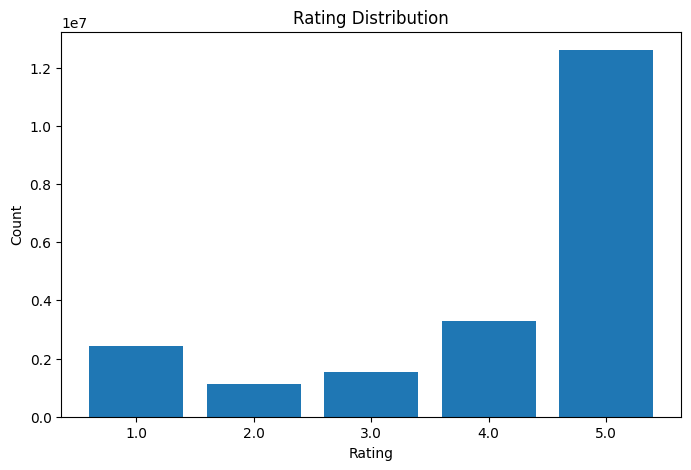

In [24]:
rating_df = pd.DataFrame(
    sorted(review_stats["ratings"].items()),
    columns=["rating", "count"]
)

rating_df["percentage"] = rating_df["count"] / rating_df["count"].sum() * 100

display(rating_df)

plt.figure(figsize=(8, 5))
plt.bar(rating_df["rating"].astype(str), rating_df["count"])
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Rating Distribution")
plt.show()

,year,count
0,1997,1
1,1998,2
2,1999,1074
3,2000,7981
4,2001,12905
5,2002,16818
6,2003,21075
7,2004,29009
8,2005,52553
9,2006,83028


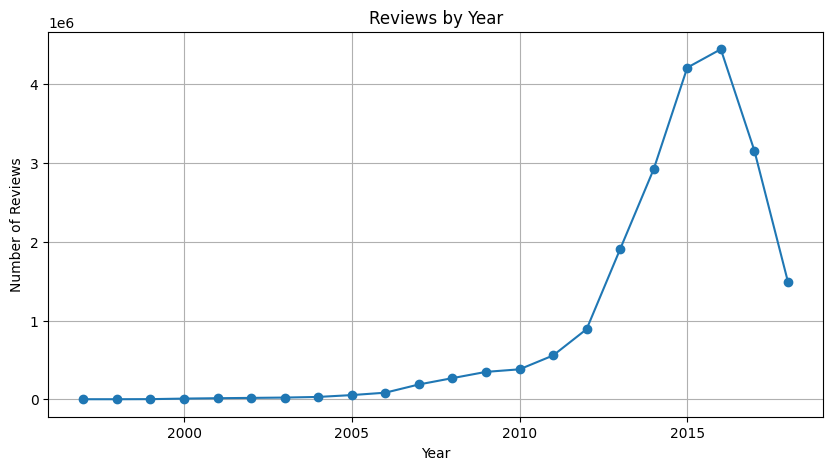

In [25]:
year_df = pd.DataFrame(
    sorted(review_stats["review_years"].items()),
    columns=["year", "count"]
)

display(year_df)

plt.figure(figsize=(10, 5))
plt.plot(year_df["year"], year_df["count"], marker="o")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.title("Reviews by Year")
plt.grid(True)
plt.show()

===== REVIEWS PER USER =====
Min: 1
Max: 633
Mean: 2.133859576227533
Median: 1.0
P90: 4.0
P95: 6.0
P99: 15.0


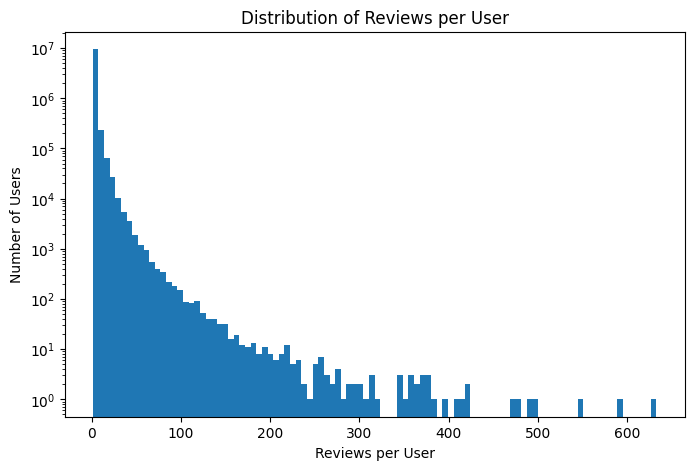

In [26]:
user_counts = np.array(list(review_stats["users_counter"].values()))

print("===== REVIEWS PER USER =====")
print("Min:", user_counts.min())
print("Max:", user_counts.max())
print("Mean:", user_counts.mean())
print("Median:", np.median(user_counts))
print("P90:", np.percentile(user_counts, 90))
print("P95:", np.percentile(user_counts, 95))
print("P99:", np.percentile(user_counts, 99))

plt.figure(figsize=(8, 5))
plt.hist(user_counts, bins=100)
plt.xlabel("Reviews per User")
plt.ylabel("Number of Users")
plt.title("Distribution of Reviews per User")
plt.yscale("log")
plt.show()

===== REVIEWS PER ITEM =====
Min: 1
Max: 28539
Mean: 27.752357271553187
Median: 3.0
P90: 40.0
P95: 92.0
P99: 449.0


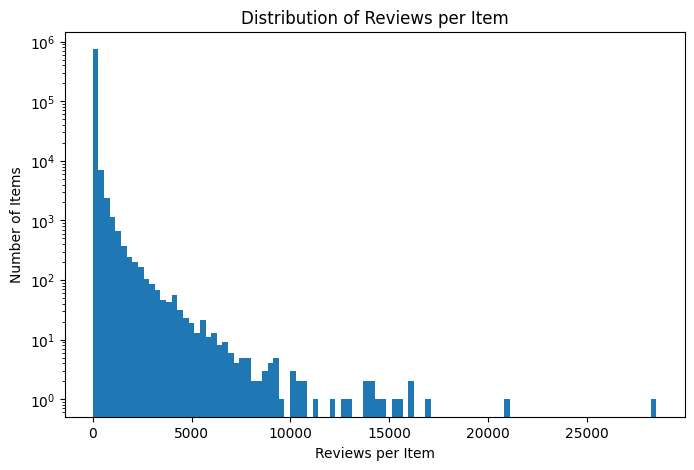

In [27]:
item_counts = np.array(list(review_stats["items_counter"].values()))

print("===== REVIEWS PER ITEM =====")
print("Min:", item_counts.min())
print("Max:", item_counts.max())
print("Mean:", item_counts.mean())
print("Median:", np.median(item_counts))
print("P90:", np.percentile(item_counts, 90))
print("P95:", np.percentile(item_counts, 95))
print("P99:", np.percentile(item_counts, 99))

plt.figure(figsize=(8, 5))
plt.hist(item_counts, bins=100)
plt.xlabel("Reviews per Item")
plt.ylabel("Number of Items")
plt.title("Distribution of Reviews per Item")
plt.yscale("log")
plt.show()

===== REVIEW TEXT LENGTH =====
Min: 0
Max: 6207
Mean: 52.76125075157115
Median: 26.0
P90: 123.0
P95: 190.0
P99: 421.0


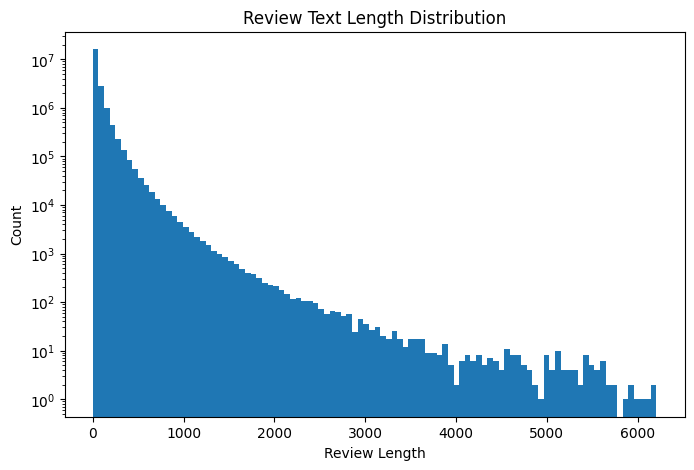

In [28]:
review_lengths = np.array(review_stats["review_lengths"])

print("===== REVIEW TEXT LENGTH =====")
print("Min:", review_lengths.min())
print("Max:", review_lengths.max())
print("Mean:", review_lengths.mean())
print("Median:", np.median(review_lengths))
print("P90:", np.percentile(review_lengths, 90))
print("P95:", np.percentile(review_lengths, 95))
print("P99:", np.percentile(review_lengths, 99))

plt.figure(figsize=(8, 5))
plt.hist(review_lengths, bins=100)
plt.xlabel("Review Length")
plt.ylabel("Count")
plt.title("Review Text Length Distribution")
plt.yscale("log")
plt.show()

## SCAN METADATA

In [29]:
def scan_metadata(path):
    total_products = 0
    
    asin_counter = Counter()
    brand_counter = Counter()
    category_counter = Counter()
    
    missing = Counter()
    
    price_values = []
    title_lengths = []
    description_lengths = []
    feature_lengths = []
    
    also_buy_lengths = []
    also_view_lengths = []
    
    required_cols = [
        "asin",
        "title",
        "feature",
        "description",
        "price",
        "imageURL",
        "imageURLHighRes",
        "also_buy",
        "also_view",
        "brand",
        "rank",
        "category"
    ]
    
    for row in read_json_gz(path):
        total_products += 1
        
        for col in required_cols:
            if col not in row or row[col] in [None, "", []]:
                missing[col] += 1
        
        asin = row.get("asin")
        if asin:
            asin_counter[asin] += 1
        
        brand = row.get("brand")
        if brand:
            brand_counter[brand] += 1
        
        categories = row.get("category", [])
        if isinstance(categories, list):
            for cat in categories:
                category_counter[cat] += 1
        
        title = row.get("title", "")
        if isinstance(title, str):
            title_lengths.append(len(title.split()))
        
        description = row.get("description", "")
        if isinstance(description, list):
            description_text = " ".join(description)
        elif isinstance(description, str):
            description_text = description
        else:
            description_text = ""
        description_lengths.append(len(description_text.split()))
        
        feature = row.get("feature", [])
        if isinstance(feature, list):
            feature_lengths.append(len(feature))
        else:
            feature_lengths.append(0)
        
        also_buy = row.get("also_buy", [])
        also_view = row.get("also_view", [])
        
        also_buy_lengths.append(len(also_buy) if isinstance(also_buy, list) else 0)
        also_view_lengths.append(len(also_view) if isinstance(also_view, list) else 0)
        
        price = row.get("price")
        if price is not None:
            try:
                price_clean = str(price).replace("$", "").replace(",", "").strip()
                price_float = float(price_clean)
                price_values.append(price_float)
            except:
                pass
    
    duplicate_asins = sum(1 for _, count in asin_counter.items() if count > 1)
    
    result = {
        "total_products": total_products,
        "num_unique_asins": len(asin_counter),
        "duplicate_asins": duplicate_asins,
        "missing": missing,
        "brand_counter": brand_counter,
        "category_counter": category_counter,
        "price_values": price_values,
        "title_lengths": title_lengths,
        "description_lengths": description_lengths,
        "feature_lengths": feature_lengths,
        "also_buy_lengths": also_buy_lengths,
        "also_view_lengths": also_view_lengths,
        "asin_counter": asin_counter
    }
    
    return result

In [30]:
meta_stats = scan_metadata(META_PATH)

In [ ]:
print("===== METADATA OVERVIEW =====")
print("Total products:", meta_stats["total_products"])
print("Unique ASINs:", meta_stats["num_unique_asins"])
print("Duplicate ASINs:", meta_stats["duplicate_asins"])

print("\n===== MISSING VALUES =====")
for k, v in meta_stats["missing"].items():
    print(k, v, f"({v / meta_stats['total_products'] * 100:.2f}%)")


    

===== METADATA OVERVIEW =====
Total products: 786445
Unique ASINs: 756077
Duplicate ASINs: 30368

===== MISSING VALUES =====
also_buy 682673 (86.80%)
also_view 559555 (71.15%)
price 476109 (60.54%)
feature 137120 (17.44%)
imageURL 251327 (31.96%)
imageURLHighRes 251327 (31.96%)
description 114045 (14.50%)
brand 5427 (0.69%)
rank 14652 (1.86%)
title 15 (0.00%)


,brand,count
0,Sony,12310
1,Generic,11524
2,Dell,7586
3,HP,7559
4,Samsung,6728
5,Canon,4727
6,Panasonic,4384
7,Asus,3786
8,Neewer,3783
9,uxcell,3716


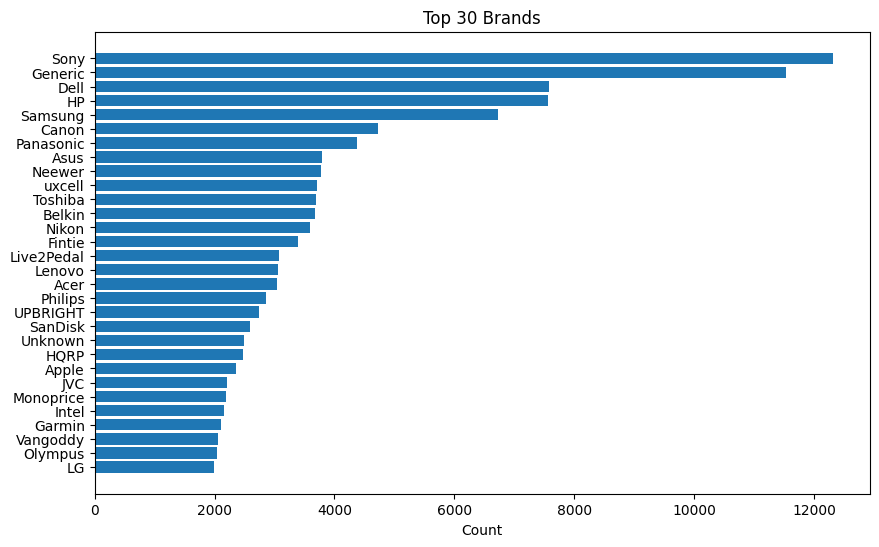

In [32]:
brand_df = pd.DataFrame(
    meta_stats["brand_counter"].most_common(30),
    columns=["brand", "count"]
)

display(brand_df)

plt.figure(figsize=(10, 6))
plt.barh(brand_df["brand"][::-1], brand_df["count"][::-1])
plt.xlabel("Count")
plt.title("Top 30 Brands")
plt.show()

,category,count
0,Electronics,786478
1,Computers & Accessories,326724
2,Camera & Photo,139313
3,Accessories & Supplies,114970
4,Audio & Video Accessories,87301
5,Tablet Accessories,75366
6,Computer Accessories & Peripherals,71985
7,Accessories,71225
8,"Bags, Cases & Sleeves",70474
9,Laptop Accessories,64562


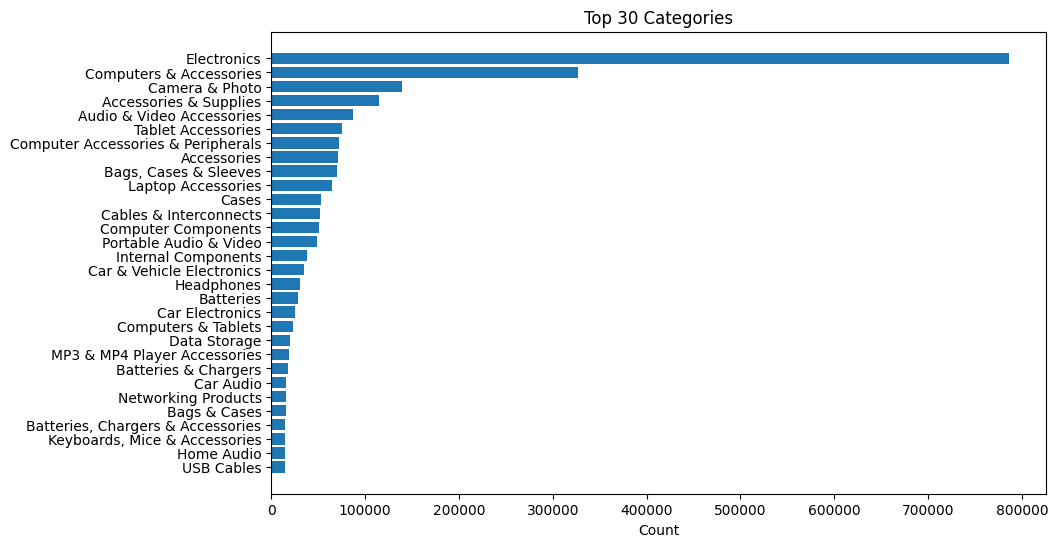

In [33]:
category_df = pd.DataFrame(
    meta_stats["category_counter"].most_common(30),
    columns=["category", "count"]
)

display(category_df)

plt.figure(figsize=(10, 6))
plt.barh(category_df["category"][::-1], category_df["count"][::-1])
plt.xlabel("Count")
plt.title("Top 30 Categories")
plt.show()

===== PRICE STATS =====
Count: 303980
Min: 0.01
Max: 79636.71
Mean: 32.211161227712346
Median: 9.99
P90: 49.1
P95: 99.49049999999988
P99: 424.95840000000084


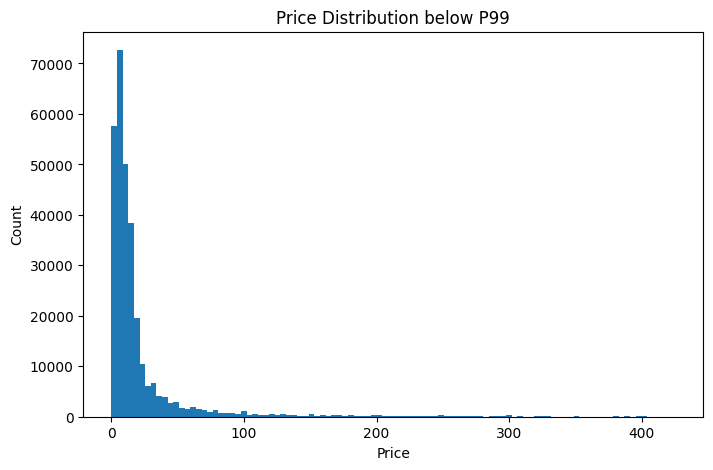

In [34]:
prices = np.array(meta_stats["price_values"])

print("===== PRICE STATS =====")
print("Count:", len(prices))
print("Min:", prices.min())
print("Max:", prices.max())
print("Mean:", prices.mean())
print("Median:", np.median(prices))
print("P90:", np.percentile(prices, 90))
print("P95:", np.percentile(prices, 95))
print("P99:", np.percentile(prices, 99))

plt.figure(figsize=(8, 5))
plt.hist(prices[prices < np.percentile(prices, 99)], bins=100)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price Distribution below P99")
plt.show()

## OVERLAP giữa reviews và metadata 

Kiểm tra xem:
- Bao nhiêu review ko có metadata
- Bao nhiêu metadata ko có reviews


In [35]:
review_items = set(review_stats["items_counter"].keys())
meta_items = set(meta_stats["asin_counter"].keys())

items_in_both = review_items & meta_items
review_items_without_meta = review_items - meta_items
meta_items_without_reviews = meta_items - review_items

print("Review items:", len(review_items))
print("Metadata items:", len(meta_items))
print("Items in both:", len(items_in_both))

print("Review items without metadata:", len(review_items_without_meta))
print("Metadata items without reviews:", len(meta_items_without_reviews))

print("Review item metadata coverage:")
print(len(items_in_both) / len(review_items) * 100)

print("Metadata item review coverage:")
print(len(items_in_both) / len(meta_items) * 100)

Review items: 756489
Metadata items: 756077
Items in both: 756061
Review items without metadata: 428
Metadata items without reviews: 16
Review item metadata coverage:
99.9434228389309
Metadata item review coverage:
99.99788381342111


## Xuất báo cáo EDA ra file

In [36]:
summary = {
    "total_reviews": review_stats["total_reviews"],
    "num_users": review_stats["num_users"],
    "num_review_items": review_stats["num_items"],
    "total_metadata_products": meta_stats["total_products"],
    "num_metadata_items": meta_stats["num_unique_asins"],
    "items_in_both": len(items_in_both),
    "review_items_without_metadata": len(review_items_without_meta),
    "metadata_items_without_reviews": len(meta_items_without_reviews),
    "sparsity": sparsity,
    "review_min_time": review_stats["min_time"],
    "review_max_time": review_stats["max_time"],
    "duplicate_user_item_pairs": review_stats["duplicate_user_item_pairs"],
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(OUT_DIR / "phase1_dataset_summary.csv", index=False)

summary_df

,total_reviews,num_users,num_review_items,total_metadata_products,num_metadata_items,items_in_both,review_items_without_metadata,metadata_items_without_reviews,sparsity,review_min_time,review_max_time,duplicate_user_item_pairs
0,20994353,9838676,756489,786445,756077,756061,428,16,0.999997,1997-12-04,2018-10-05,435899


Lưu distribution ra CSV

In [37]:
rating_df.to_csv(OUT_DIR / "rating_distribution.csv", index=False)
year_df.to_csv(OUT_DIR / "reviews_by_year.csv", index=False)
brand_df.to_csv(OUT_DIR / "top_brands.csv", index=False)
category_df.to_csv(OUT_DIR / "top_categories.csv", index=False)

print("Saved EDA outputs to:", OUT_DIR)

Saved EDA outputs to: ..\outputs\eda
